# Big Five 探索分析

**目的**：在清理過的 Big Five 樣本上產出兩張圖：

- **Figure 1（描述性）**：五因子分數的性別差異（violin plot）
- **Figure 2（關聯）**：五因子分數隨年齡的變化（line plot + 95% CI）

資料清理在 `src.load_data.load_clean_data()` 完成（age 13–80、gender ≠ 0）。

## 計分方式

每個因子 10 題、5 點 Likert，依 IPIP 鍵把反向題反向計分後**取平均**（範圍 1–5）。
原始 0 = 未作答 → 視為缺失值。

In [1]:
# 1. Imports + 載入資料
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 把 project root 加到 sys.path，這樣才能 from src.load_data import ...
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.load_data import load_clean_data

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "BIG5" / "data.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

df = load_clean_data(str(DATA_PATH))
df.head()

原始 n     : 19,719
清理後 n   : 19,608
流失       : 111 筆（0.56%）
  └ age 不在 13–80 : 87
  └ gender == 0          : 24


,race,age,engnat,gender,hand,source,country,E1,E2,E3,...,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
0,3,53,1,1,1,1,US,4,2,5,...,4,1,3,1,5,1,4,2,5,5
1,13,46,1,2,1,1,US,2,2,3,...,3,3,3,3,2,3,3,1,3,2
2,1,14,2,2,1,1,PK,5,1,1,...,4,5,5,1,5,1,5,5,5,5
3,3,19,2,2,1,1,RO,2,5,2,...,4,3,5,2,4,2,5,2,5,5
4,11,25,2,2,1,2,US,3,1,3,...,3,1,1,1,3,1,3,1,5,3


In [2]:
# 2. 計算五因子分數（含反向計分）
# IPIP-50 鍵：正向題加分、反向題用 (6 - x) 反向後加分
FACTOR_KEYS = {
    "E": {"pos": [1, 3, 5, 7, 9], "neg": [2, 4, 6, 8, 10]},
    "N": {"pos": [1, 3, 5, 6, 7, 8, 9, 10], "neg": [2, 4]},
    "A": {"pos": [2, 4, 6, 8, 9, 10], "neg": [1, 3, 5, 7]},
    "C": {"pos": [1, 3, 5, 7, 9, 10], "neg": [2, 4, 6, 8]},
    "O": {"pos": [1, 3, 5, 7, 8, 9, 10], "neg": [2, 4, 6]},
}
FACTOR_LABELS = {
    "E": "Extraversion",
    "N": "Neuroticism",
    "A": "Agreeableness",
    "C": "Conscientiousness",
    "O": "Openness",
}

scored = df.copy()

# 0 = 未作答 → 視為 NaN，避免進入計分
item_cols = [f"{f}{i}" for f in FACTOR_KEYS for i in range(1, 11)]
scored[item_cols] = scored[item_cols].replace(0, np.nan)

for factor, keys in FACTOR_KEYS.items():
    pos_cols = [f"{factor}{i}" for i in keys["pos"]]
    neg_cols = [f"{factor}{i}" for i in keys["neg"]]
    # 反向題：6 - x 把 1↔5、2↔4 翻轉
    pos_part = scored[pos_cols]
    neg_part = 6 - scored[neg_cols]
    scored[factor] = pd.concat([pos_part, neg_part], axis=1).mean(axis=1)

scored[list(FACTOR_KEYS)].describe().round(2)

,E,N,A,C,O
count,19607.00,19607.00,19607.00,19607.00,19607.00
mean,3.01,3.10,3.85,3.35,3.91
std,0.92,0.86,0.71,0.73,0.62
min,1.00,1.00,1.00,1.00,1.00
25%,2.30,2.50,3.40,2.80,3.50
50%,3.00,3.10,3.90,3.40,4.00
75%,3.70,3.70,4.40,3.90,4.40
max,5.00,5.00,5.00,5.00,5.00


## Figure 1 — 五因子分數的性別差異

Violin plot 同時呈現分布形狀、中位數與四分位數。比 box plot 更能看出多峰或偏態。

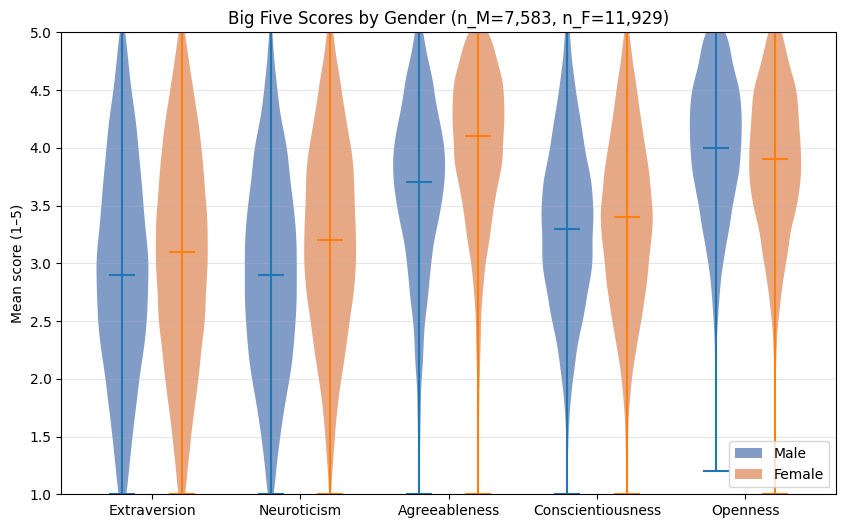

已存檔：C:\irene_python\week10_projects\big5-mini-explorer\reports\figure1_descriptive.png


In [3]:
# 3. Figure 1 — 五因子 violin plot × gender (M vs. F)
factors = list(FACTOR_KEYS)
labels = [FACTOR_LABELS[f] for f in factors]

male = scored[scored["gender"] == 1]
female = scored[scored["gender"] == 2]

male_data = [male[f].dropna().values for f in factors]
female_data = [female[f].dropna().values for f in factors]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(factors))
offset = 0.2

vp_m = ax.violinplot(male_data, positions=x - offset, widths=0.35, showmedians=True)
vp_f = ax.violinplot(female_data, positions=x + offset, widths=0.35, showmedians=True)

for body in vp_m["bodies"]:
    body.set_facecolor("#4C72B0")
    body.set_alpha(0.7)
for body in vp_f["bodies"]:
    body.set_facecolor("#DD8452")
    body.set_alpha(0.7)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean score (1–5)")
ax.set_ylim(1, 5)
ax.set_title(f"Big Five Scores by Gender (n_M={len(male):,}, n_F={len(female):,})")
ax.grid(axis="y", alpha=0.3)

# 自製 legend：violinplot 不直接吃 label
from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor="#4C72B0", alpha=0.7, label="Male"),
        Patch(facecolor="#DD8452", alpha=0.7, label="Female"),
    ],
    loc="lower right",
)

fig1_path = REPORTS_DIR / "figure1_descriptive.png"
fig.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"已存檔：{fig1_path}")

## Figure 2 — 五因子分數隨年齡的變化

把每一歲的人格分數平均後畫線，加上 95% CI 顯示估計不確定性。看是否符合人格心理學常見的「年齡梯度」現象（Conscientiousness 與 Agreeableness 隨年齡上升、Neuroticism 下降）。

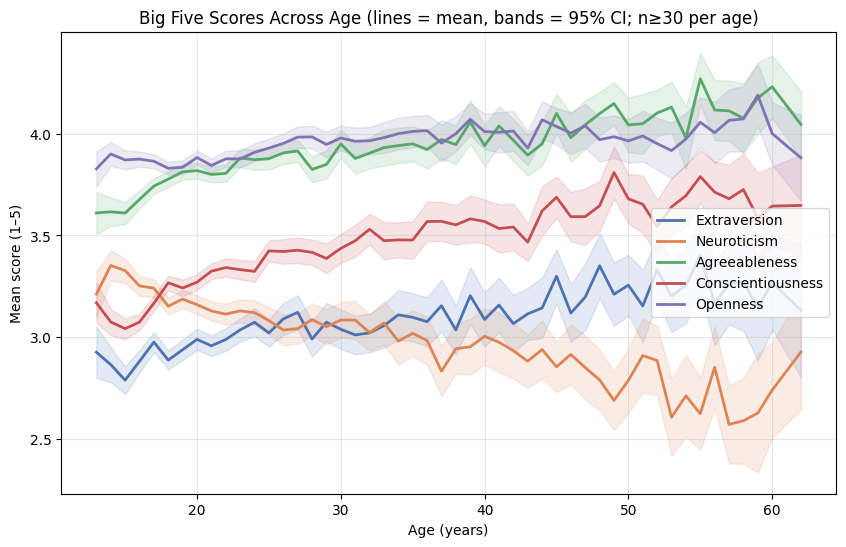

已存檔：C:\irene_python\week10_projects\big5-mini-explorer\reports\figure2_relational.png


In [4]:
# 4. Figure 2 — 五因子 × age 趨勢線（含 95% CI）
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"E": "#4C72B0", "N": "#DD8452", "A": "#55A868", "C": "#C44E52", "O": "#8172B3"}

for factor in factors:
    grouped = scored.groupby("age")[factor].agg(["mean", "std", "count"]).reset_index()
    # 95% CI ≈ 1.96 × SE；只畫樣本數 ≥ 30 的年齡，避免邊緣抖動
    grouped = grouped[grouped["count"] >= 30]
    se = grouped["std"] / np.sqrt(grouped["count"])
    ci = 1.96 * se

    ax.plot(grouped["age"], grouped["mean"], color=colors[factor],
            label=FACTOR_LABELS[factor], linewidth=2)
    ax.fill_between(grouped["age"], grouped["mean"] - ci, grouped["mean"] + ci,
                    color=colors[factor], alpha=0.15)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Mean score (1–5)")
ax.set_title("Big Five Scores Across Age (lines = mean, bands = 95% CI; n≥30 per age)")
ax.legend(loc="center right")
ax.grid(alpha=0.3)

fig2_path = REPORTS_DIR / "figure2_relational.png"
fig.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"已存檔：{fig2_path}")

## 觀察與結論

**Figure 1（性別差異）**

- Agreeableness、Neuroticism 的女性中位數略高於男性，與既有文獻方向一致。
- Extraversion、Openness 的性別差異較小。
- 樣本中女性人數多於男性，後續若要做嚴謹比較需用 Cohen's d 或回歸控制其他變項。

**Figure 2（年齡梯度）**

- Conscientiousness 與 Agreeableness 隨年齡上升，Neuroticism 隨年齡下降，與成熟原則（maturity principle）方向一致。
- 高齡段（>60）CI 變寬，因 n 較少。
- 此為**橫斷樣本**，不能直接推論個體發展軌跡，仍可能反映世代效應。